<a href="https://colab.research.google.com/github/Gyuseo-stack/Statistics_DGS/blob/main/Digital_lifestyle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/sample_data/Data.csv')
display(df.head())

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,...,3.353627,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,...,2.908147,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,...,2.889213,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,...,3.097488,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,...,2.786098,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000


## 데이터 파악

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        3500 non-null   int64  
 1   age                       3500 non-null   int64  
 2   gender                    3500 non-null   object 
 3   region                    3500 non-null   object 
 4   income_level              3500 non-null   object 
 5   education_level           3500 non-null   object 
 6   daily_role                3500 non-null   object 
 7   device_hours_per_day      3500 non-null   float64
 8   phone_unlocks             3500 non-null   int64  
 9   notifications_per_day     3500 non-null   int64  
 10  social_media_mins         3500 non-null   int64  
 11  study_mins                3500 non-null   int64  
 12  physical_activity_days    3500 non-null   float64
 13  sleep_hours               3500 non-null   float64
 14  sleep_qu

### Demographic
**age**: 나이

**gender**: 성별

**region**: 거주 지역

**income_level**: 소득 수준 구간

**education_level**: 최종 학력

**daily_role**: 일상 역할 (학생, 직장인 등)


### Digital Behavior (디지털 사용 패턴)


**device_hours_per_day**: 하루 평균 디바이스 사용 시간(시간)

**phone_unlocks**: 하루 평균 스마트폰 잠금 해제 횟수

**notifications_per_day**: 하루 평균 알림 수

**social_media_mins**: 하루 소셜미디어 사용 시간(분)

**study_mins**: 하루 학습/공부 시간(분)

**device_type**: 주 사용 디바이스 유형


### 🏃 Lifestyle / Health Habits


**physical_activity_days**: 주간 신체 활동 일수

**sleep_hours**: 하루 평균 수면 시간

**sleep_quality**: 수면의 질 점수 (연속형)


### Mental Health & Cognitive Indicators


**anxiety_score**: 불안 수준

**depression_score**: 우울 수준

**stress_level**: 스트레스 수준

**happiness_score**: 전반적 행복감

**focus_score**: 집중도

**productivity_score**: 생산성 인식 점수

**digital_dependence_score**: 디지털 의존도 종합 점수

### Risk Indicator

**high_risk_flag**:
디지털 사용 강도 + 정서 지표를 종합한 고위험군 여부 (0/1)

In [7]:
df.describe()

,id,age,device_hours_per_day,phone_unlocks,notifications_per_day,social_media_mins,study_mins,physical_activity_days,sleep_hours,sleep_quality,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,productivity_score,digital_dependence_score
count,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000,3500.000000
mean,1750.500000,28.078571,7.317677,147.107429,335.117143,159.362857,108.116571,3.350000,7.254481,2.708848,7.183858,8.830000,5.076560,6.418568,41.598600,0.201429,65.299301,36.684152
std,1010.507298,9.352385,3.239838,67.770656,239.678612,132.748048,79.796273,1.877976,1.291879,1.101105,5.043220,5.738959,3.403503,3.019828,23.764574,0.401125,9.664716,14.115504
min,1.000000,13.000000,0.280000,9.000000,22.000000,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,33.000000,5.600000
25%,875.750000,21.000000,4.867500,96.000000,170.000000,68.000000,42.000000,2.000000,6.410545,1.919438,4.000000,4.000000,1.341488,4.000000,24.750000,0.000000,59.000000,26.200000
50%,1750.500000,27.000000,6.760000,136.000000,268.000000,119.000000,102.000000,3.000000,7.291580,2.907819,6.000000,8.000000,4.809726,7.500000,44.000000,0.000000,65.299301,35.300000
75%,2625.250000,34.000000,9.152500,187.000000,434.000000,204.000000,163.000000,5.000000,8.162298,3.276968,8.845008,13.000000,8.794302,8.900000,59.000000,0.000000,71.000000,45.100000
max,3500.000000,50.000000,17.160000,374.000000,1211.000000,631.000000,418.000000,7.000000,11.004566,5.000000,27.154217,27.000000,10.000000,10.000000,100.000000,1.000000,95.000000,89.200000


## 결측치 파악

In [8]:
df.isnull().sum()

,0
id,0
age,0
gender,0
region,0
income_level,0
education_level,0
daily_role,0
device_hours_per_day,0
phone_unlocks,0
notifications_per_day,0


**결측치는 없음**

## EDA

### 수치형 변수

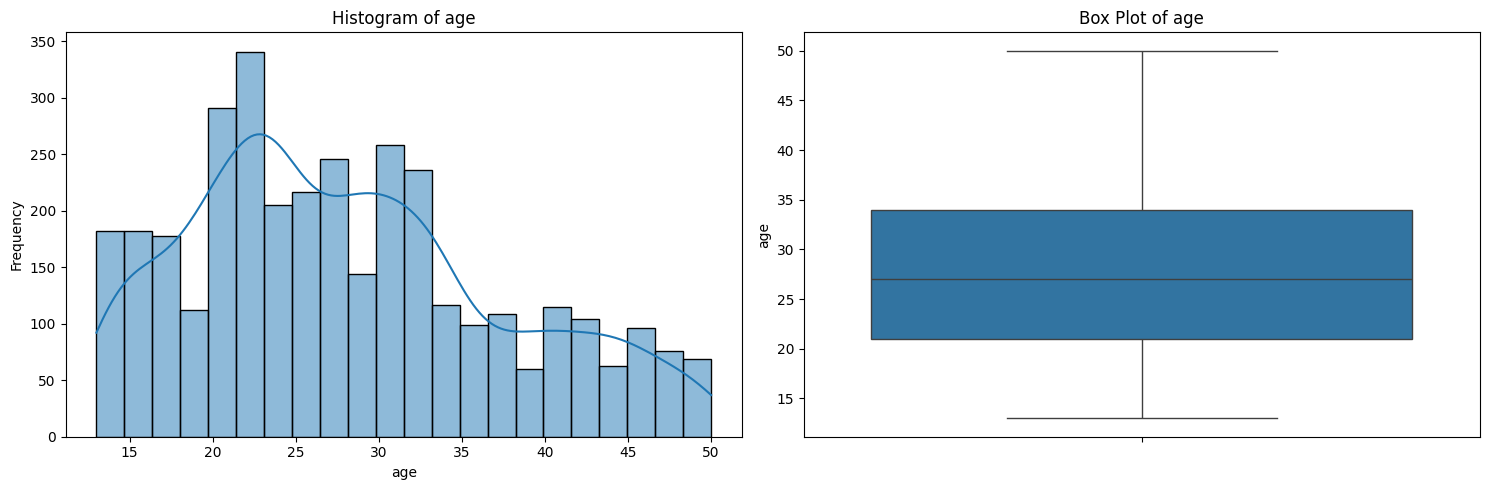

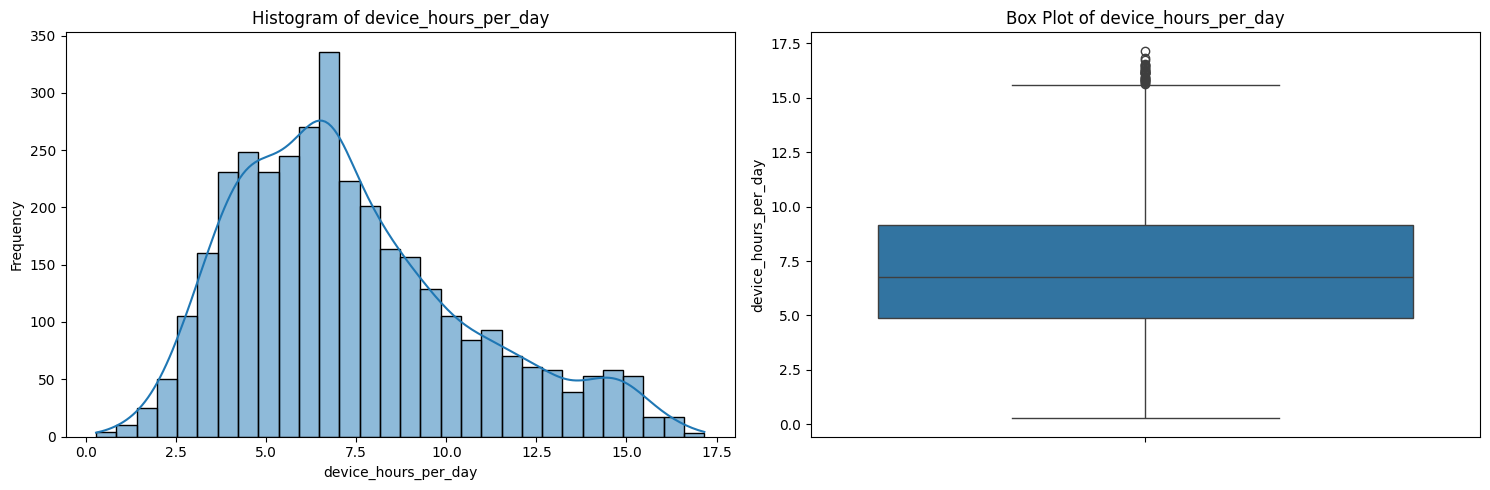

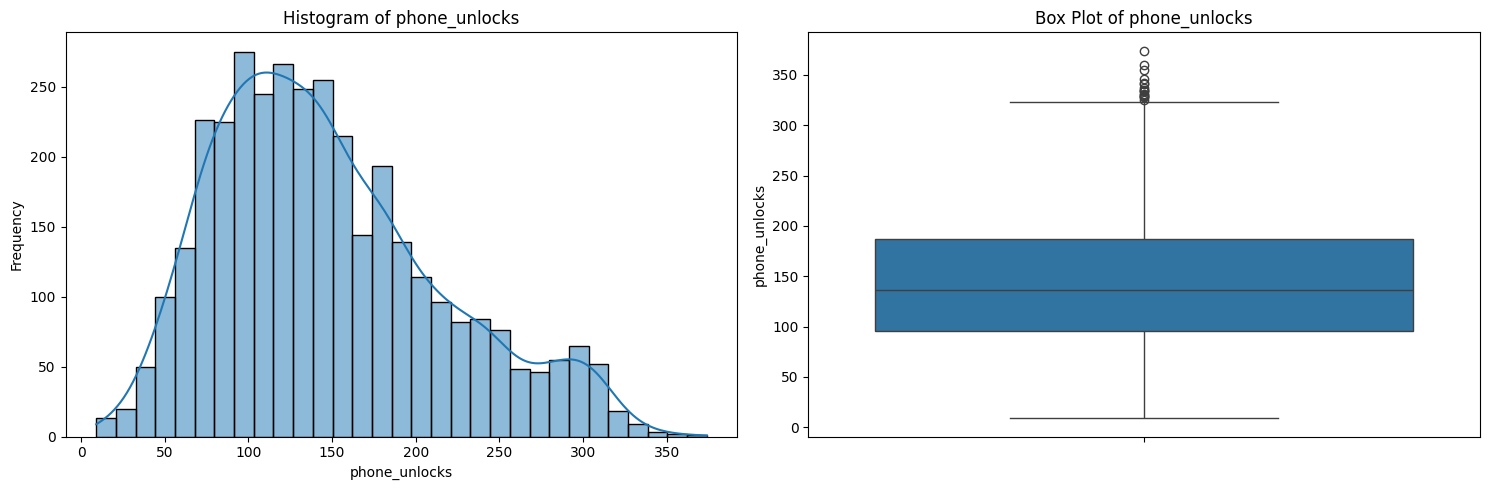

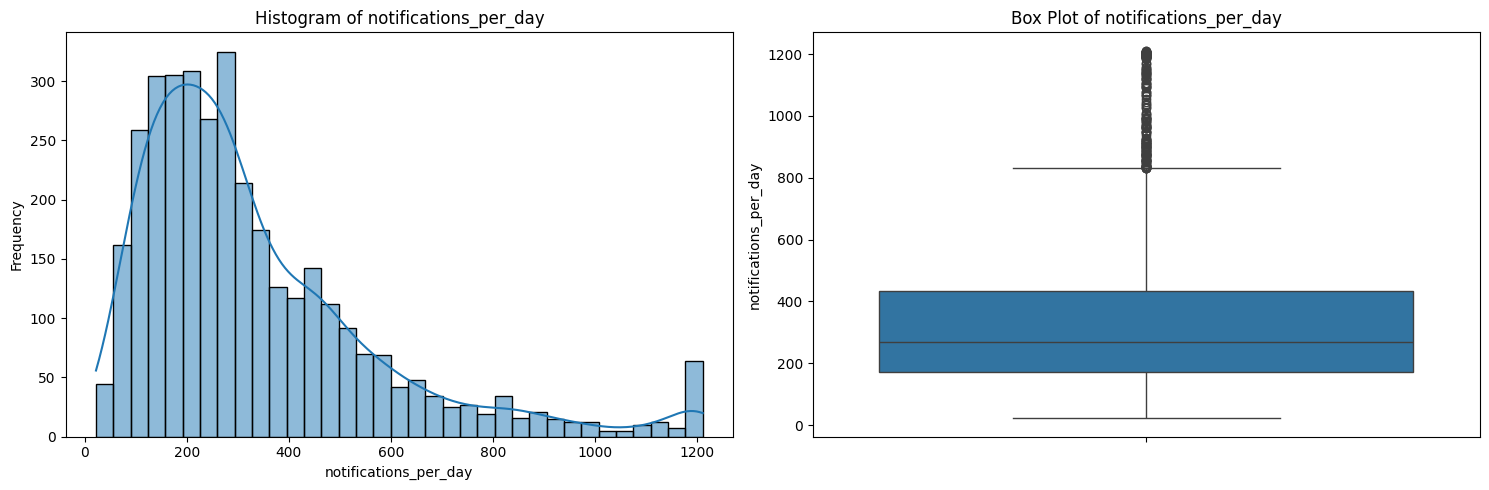

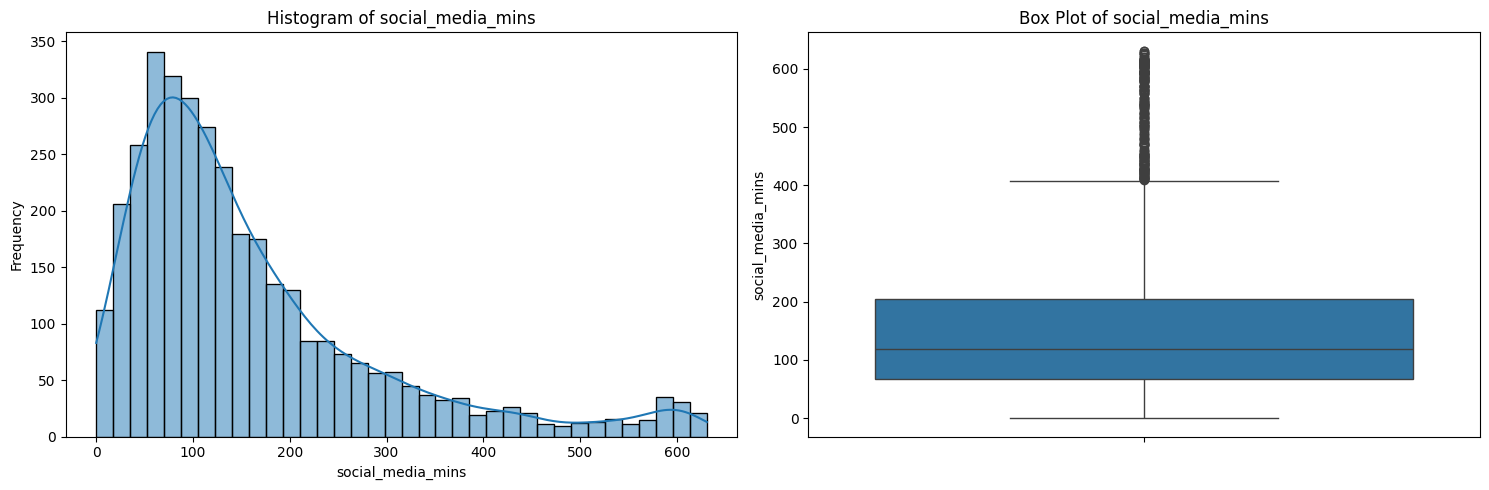

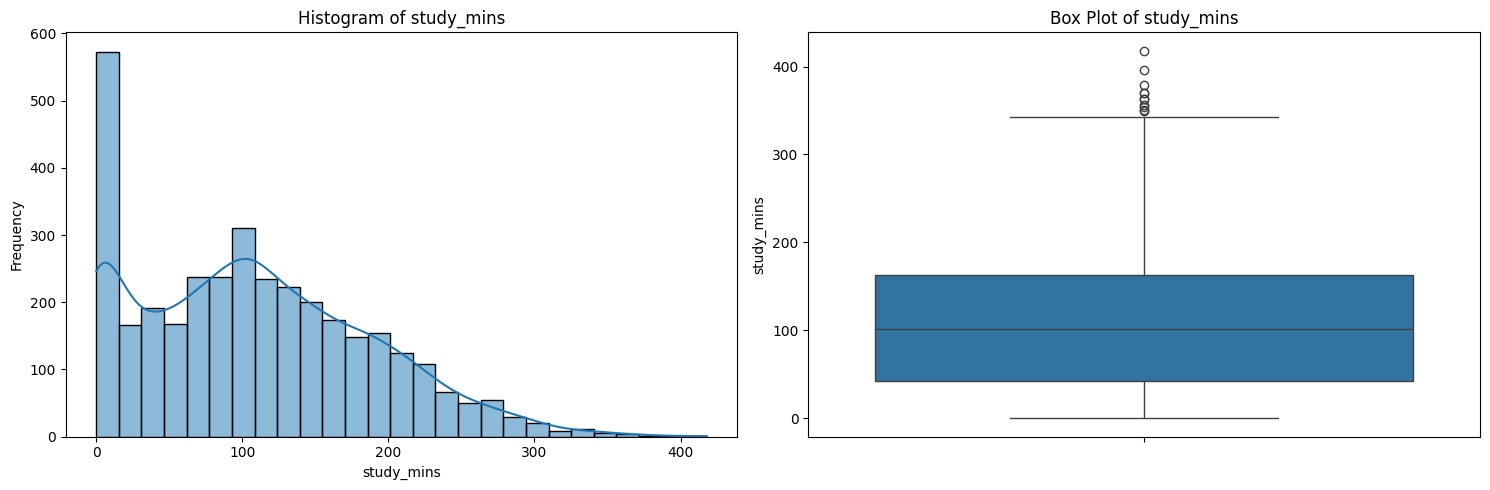

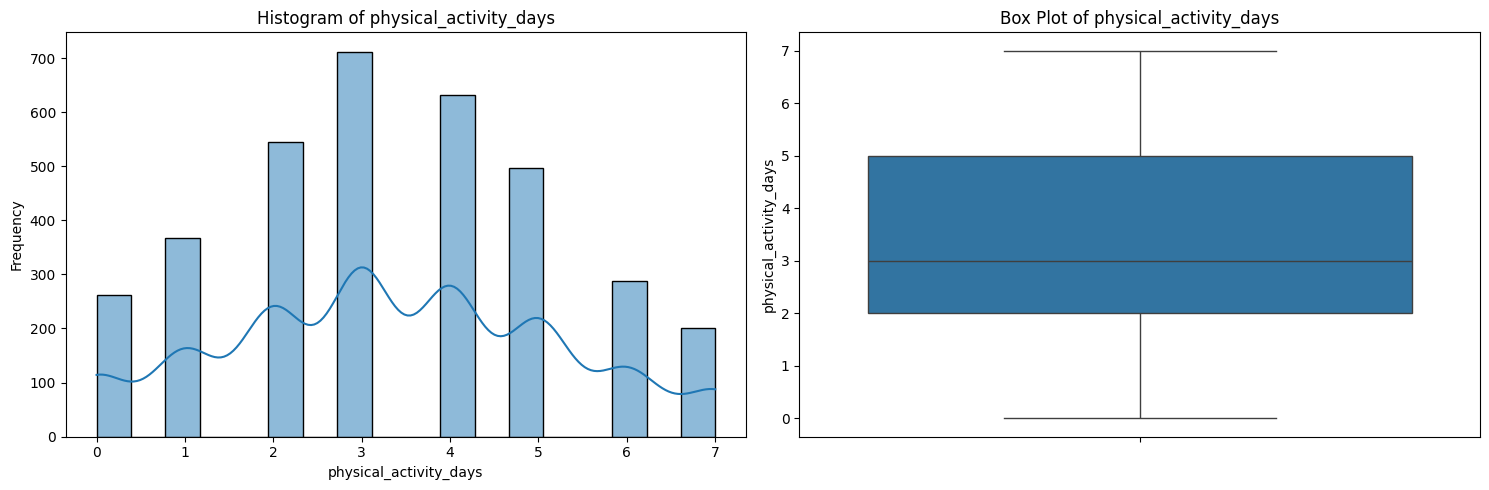

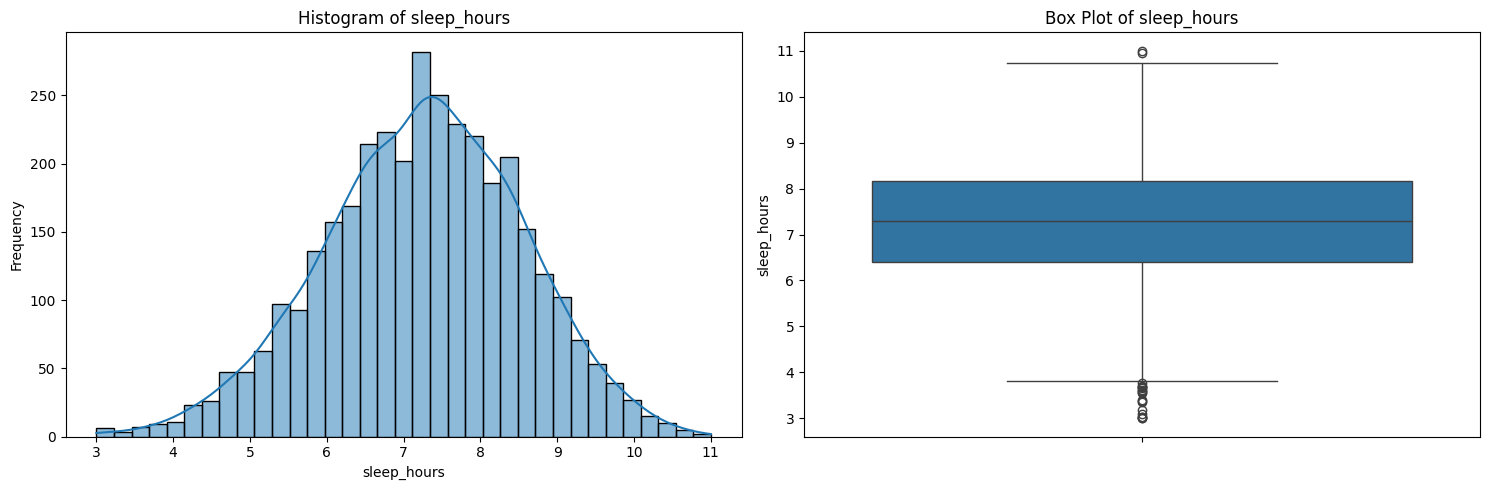

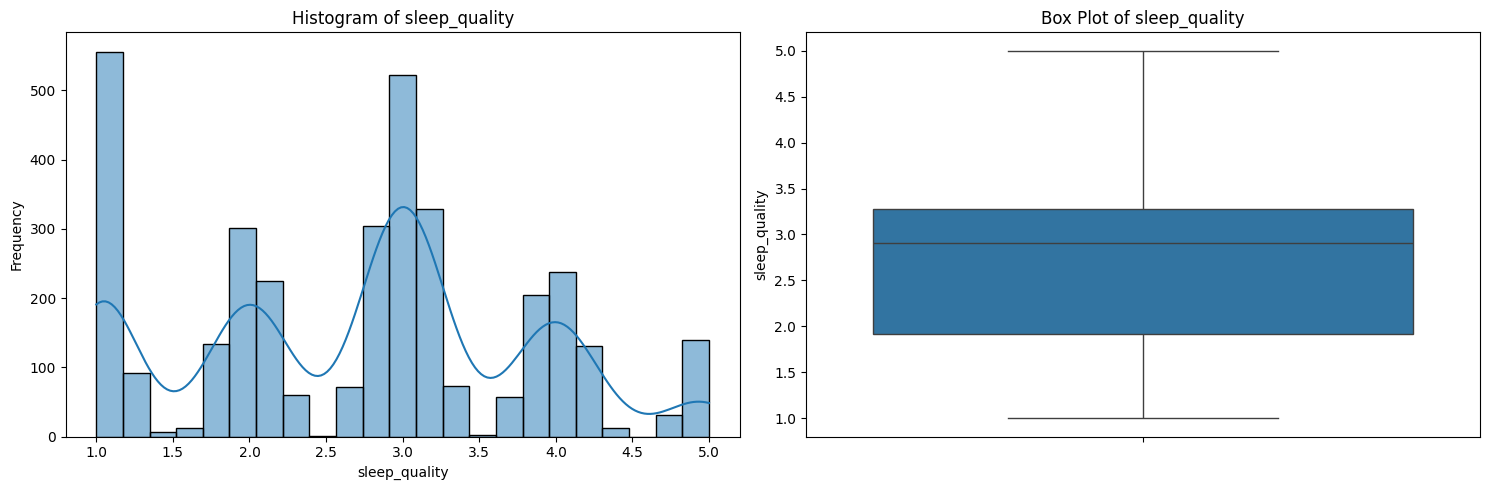

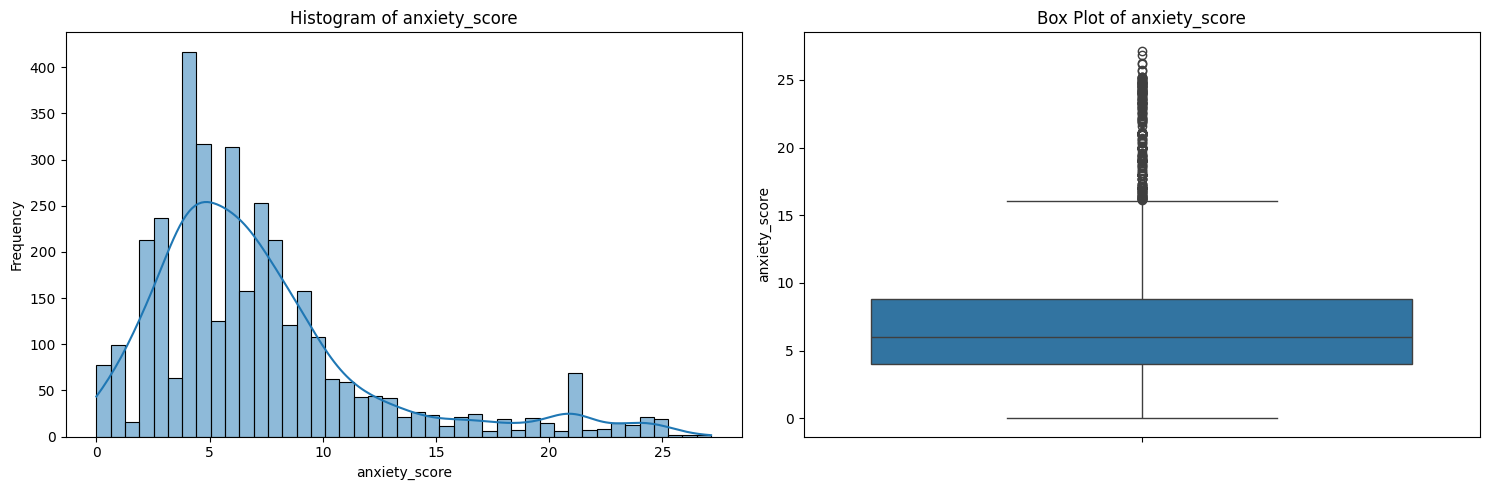

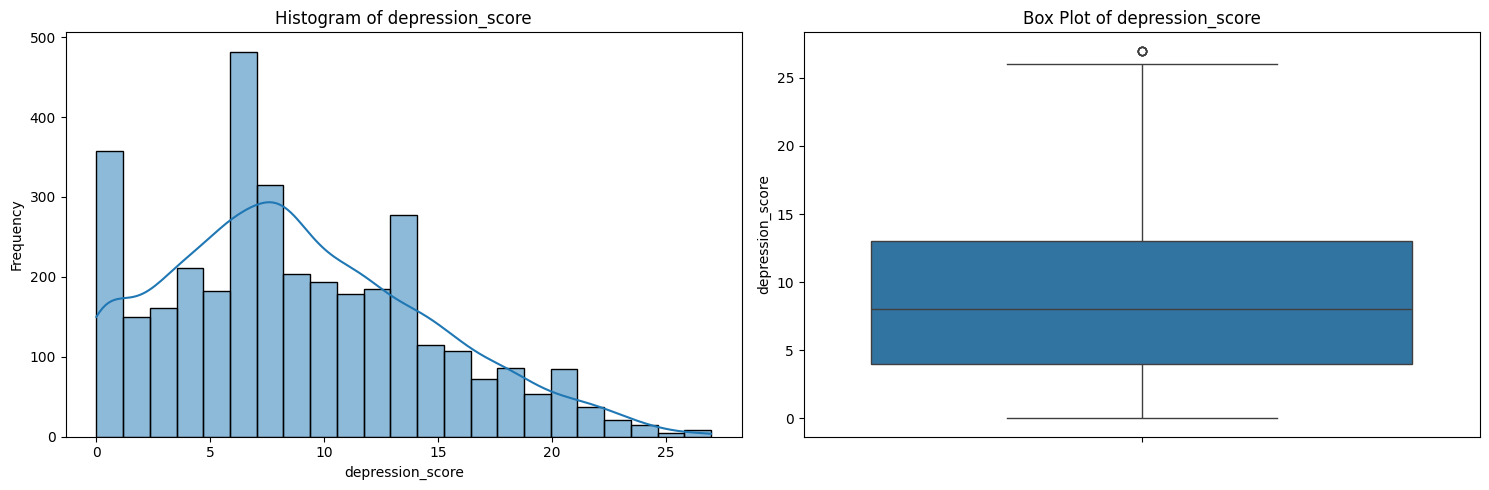

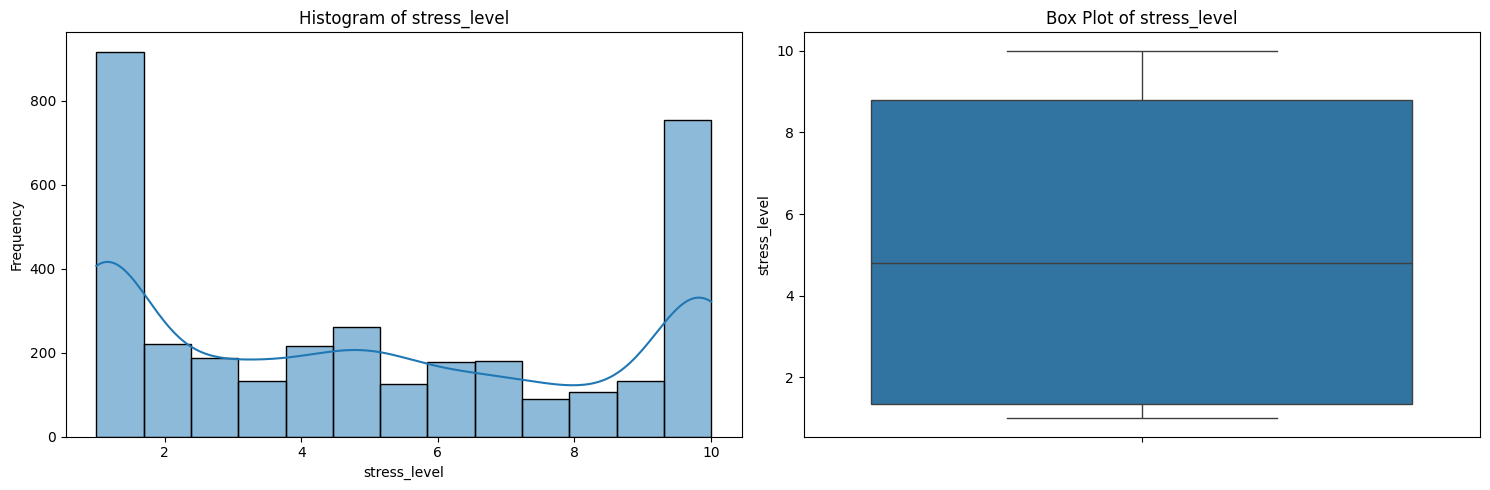

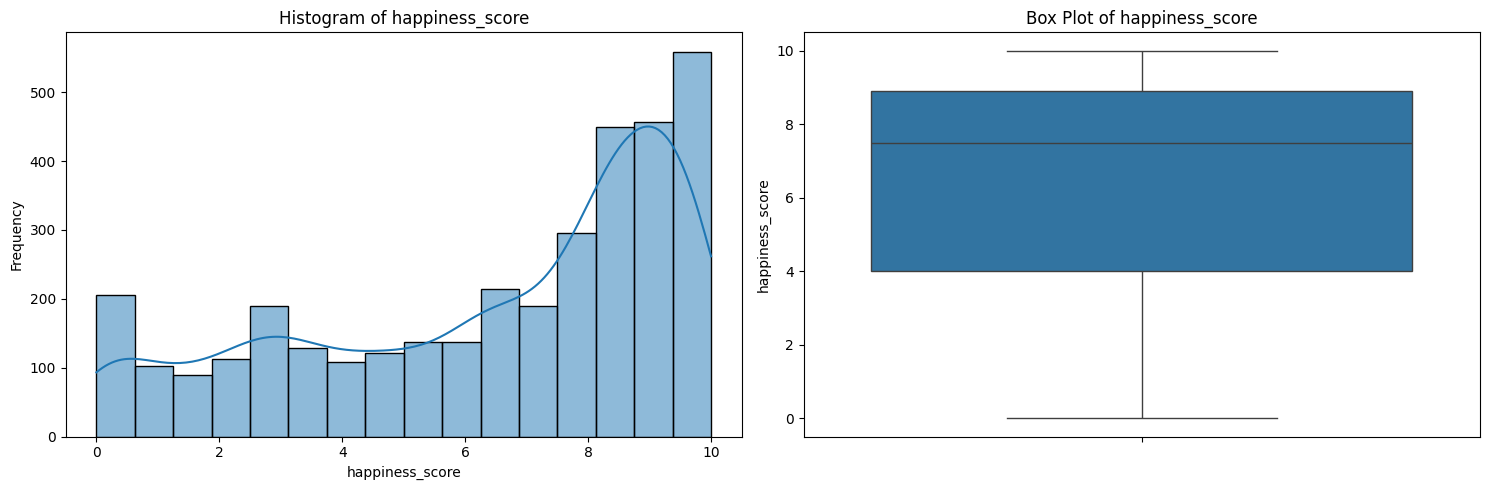

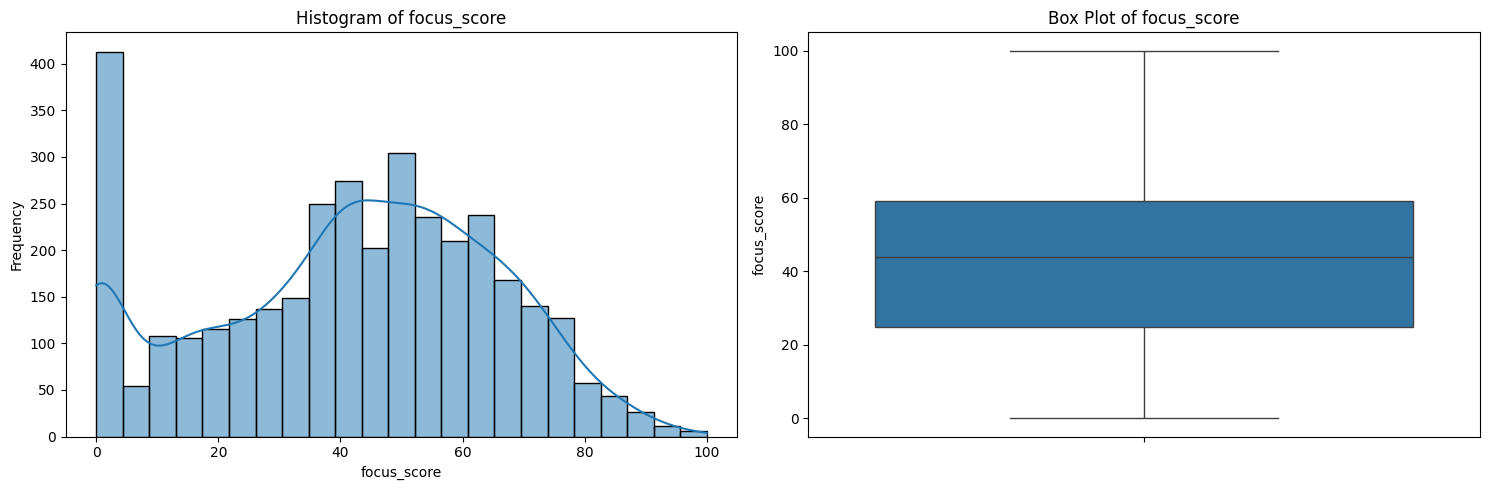

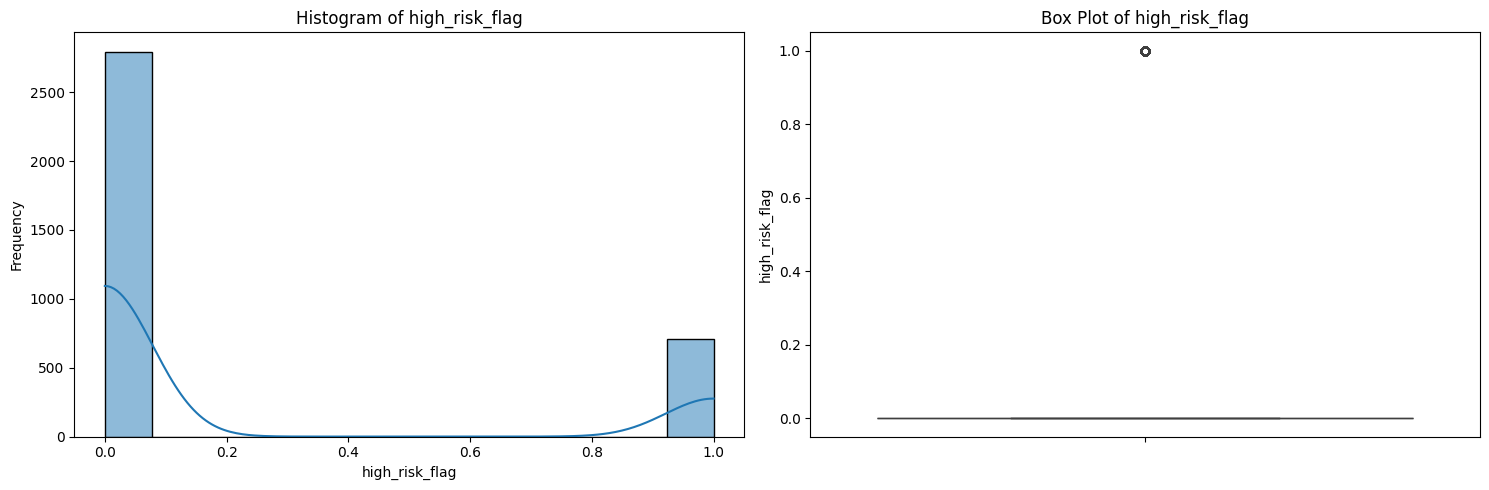

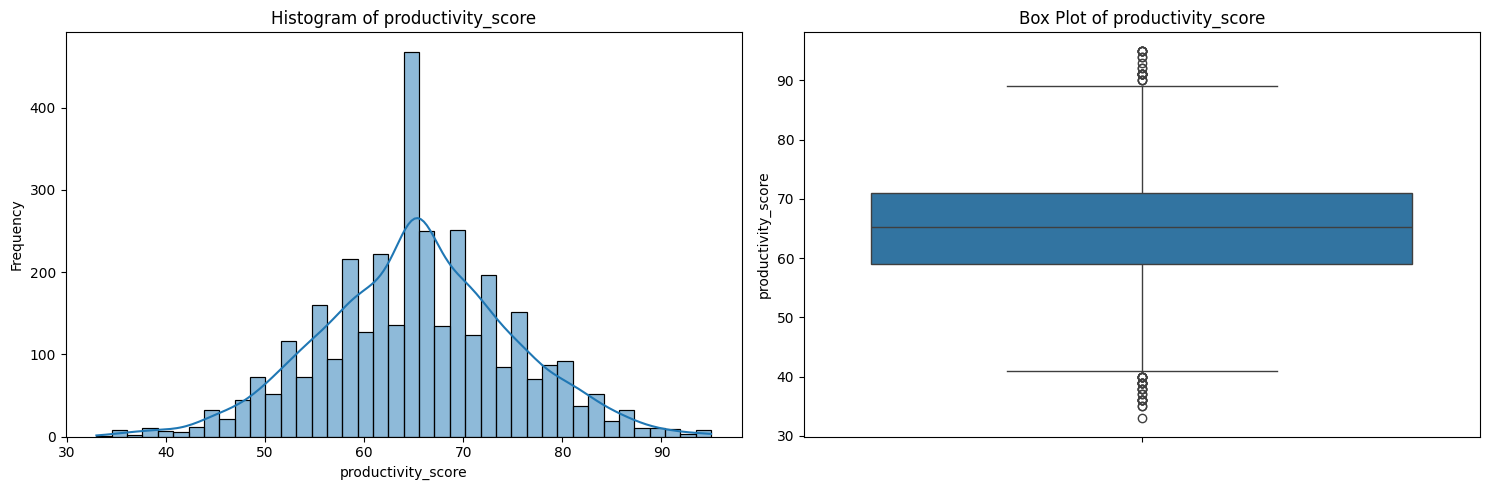

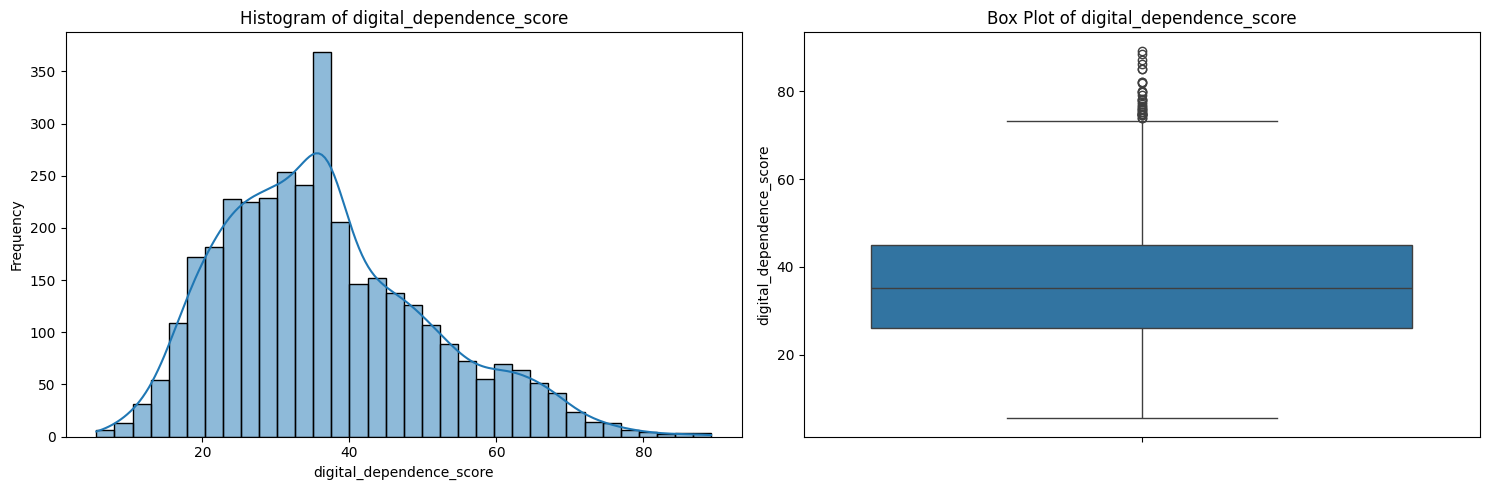

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Exclude 'id' as it is an identifier
numerical_cols = [col for col in numerical_cols if col not in ['id']]

for col in numerical_cols:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(y=df[col], ax=axes[1])
    axes[1].set_title(f'Box Plot of {col}')
    axes[1].set_ylabel(col)

    plt.tight_layout()
    plt.show()

- **notifications_per_day,
social_media_mins,
anxiety_score, digital_dependence_score**에 이상치 많음

- **study_mins**는 공부 시간 분포가 0에 가까운 값이 많은 편

- **sleep_hours**는 정규분포에 가까운 분포를 보임

- **High_risk_flag**는 클래스 불균형 분포를 보임

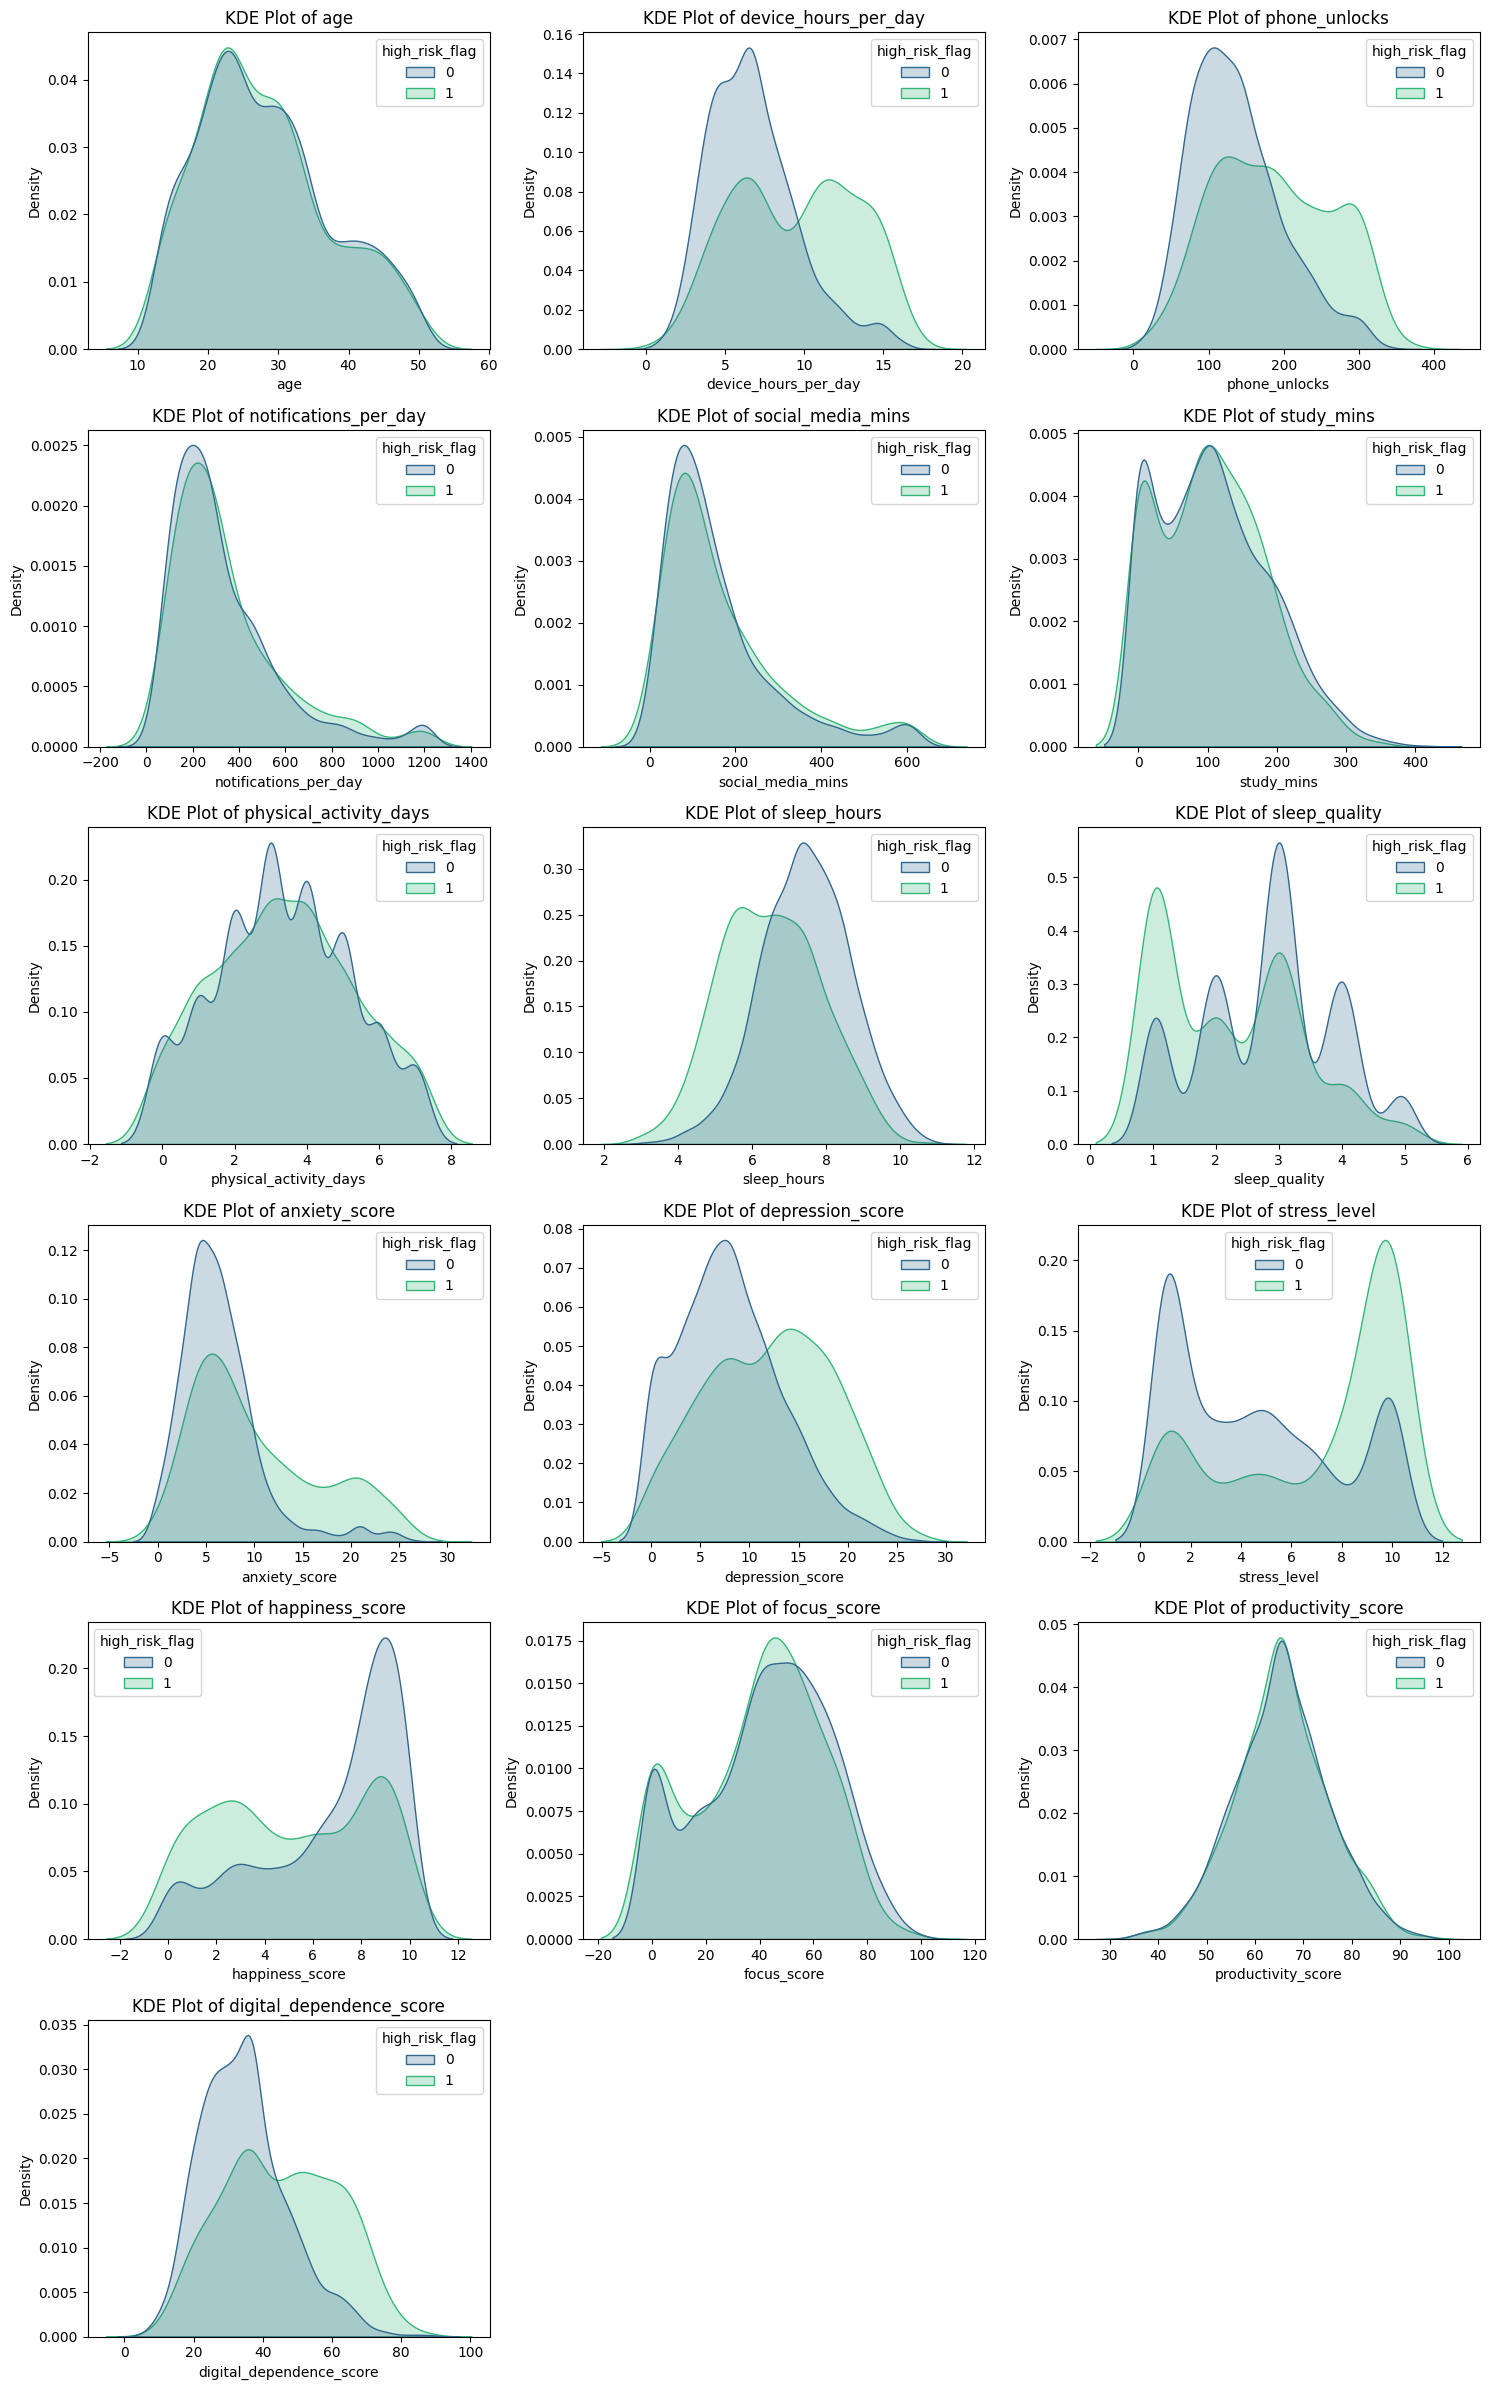

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id', 'high_risk_flag']]

# Ensure 'high_risk_flag' is treated as a categorical variable for hue
df['high_risk_flag'] = df['high_risk_flag'].astype(str)

n_cols = 3 # Number of columns for subplots
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=col, hue='high_risk_flag', fill=True, common_norm=False, palette='viridis', ax=axes[i])
    axes[i].set_title(f'KDE Plot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- 고위험군, 저위험군 모두 성인 초년층이 가장 많음
- 고위험층이 디바이스 사용 시간이 확실히 많음
- 고위험군은 평균 수면 시간이 짧고, 수면 질 점수도 낮게 분포
- 고위험군에서 **불안,우울,스트레스 점수**가 모두 낮게 나옴

### 파생변수 생성

**age_band**

In [17]:
df['age_band'] = (df['age'] // 10) * 10
display(df.head())

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,anxiety_score,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score,age_band
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,...,9.926651,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000,40
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,...,4.000000,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000,20
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,...,4.000000,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000,30
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,...,7.093357,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152,40
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,...,7.028125,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000,20


**digital_dependence_level**

In [18]:
q1 = df['digital_dependence_score'].quantile(1/3)
q2 = df['digital_dependence_score'].quantile(2/3)

# Create the digital_dependence_level column based on quantiles
df['digital_dependence_level'] = pd.cut(df['digital_dependence_score'],
                                        bins=[-float('inf'), q1, q2, float('inf')],
                                        labels=['Low', 'Medium', 'High'],
                                        right=True)

display(df[['digital_dependence_score', 'digital_dependence_level']].head())
display(df['digital_dependence_level'].value_counts())

,digital_dependence_score,digital_dependence_level
0,25.700000,Low
1,30.100000,Medium
2,40.600000,High
3,36.684152,Medium
4,48.400000,High


,count
digital_dependence_level,
Low,1174
Medium,1165
High,1161


In [29]:
df.head()

,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score,age_band,digital_dependence_level
0,1,40,Female,Asia,High,High School,Part-time/Shift,3.54,45,561,...,5.0,6.593289,8.0,23.0,0,Android,70.000000,25.700000,40,Low
1,2,27,Male,Africa,Lower-Mid,Master,Full-time Employee,5.65,100,393,...,4.0,4.126926,8.1,35.0,0,Laptop,64.000000,30.100000,20,Medium
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,...,8.0,1.429139,7.6,15.0,0,Android,65.299301,40.600000,30,High
3,4,41,Female,Middle East,Low,Master,Caregiver/Home,4.05,94,268,...,9.0,4.995512,7.8,28.0,1,Tablet,80.000000,36.684152,40,Medium
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,...,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.400000,20,High


### 수치형 변수의 상관관계

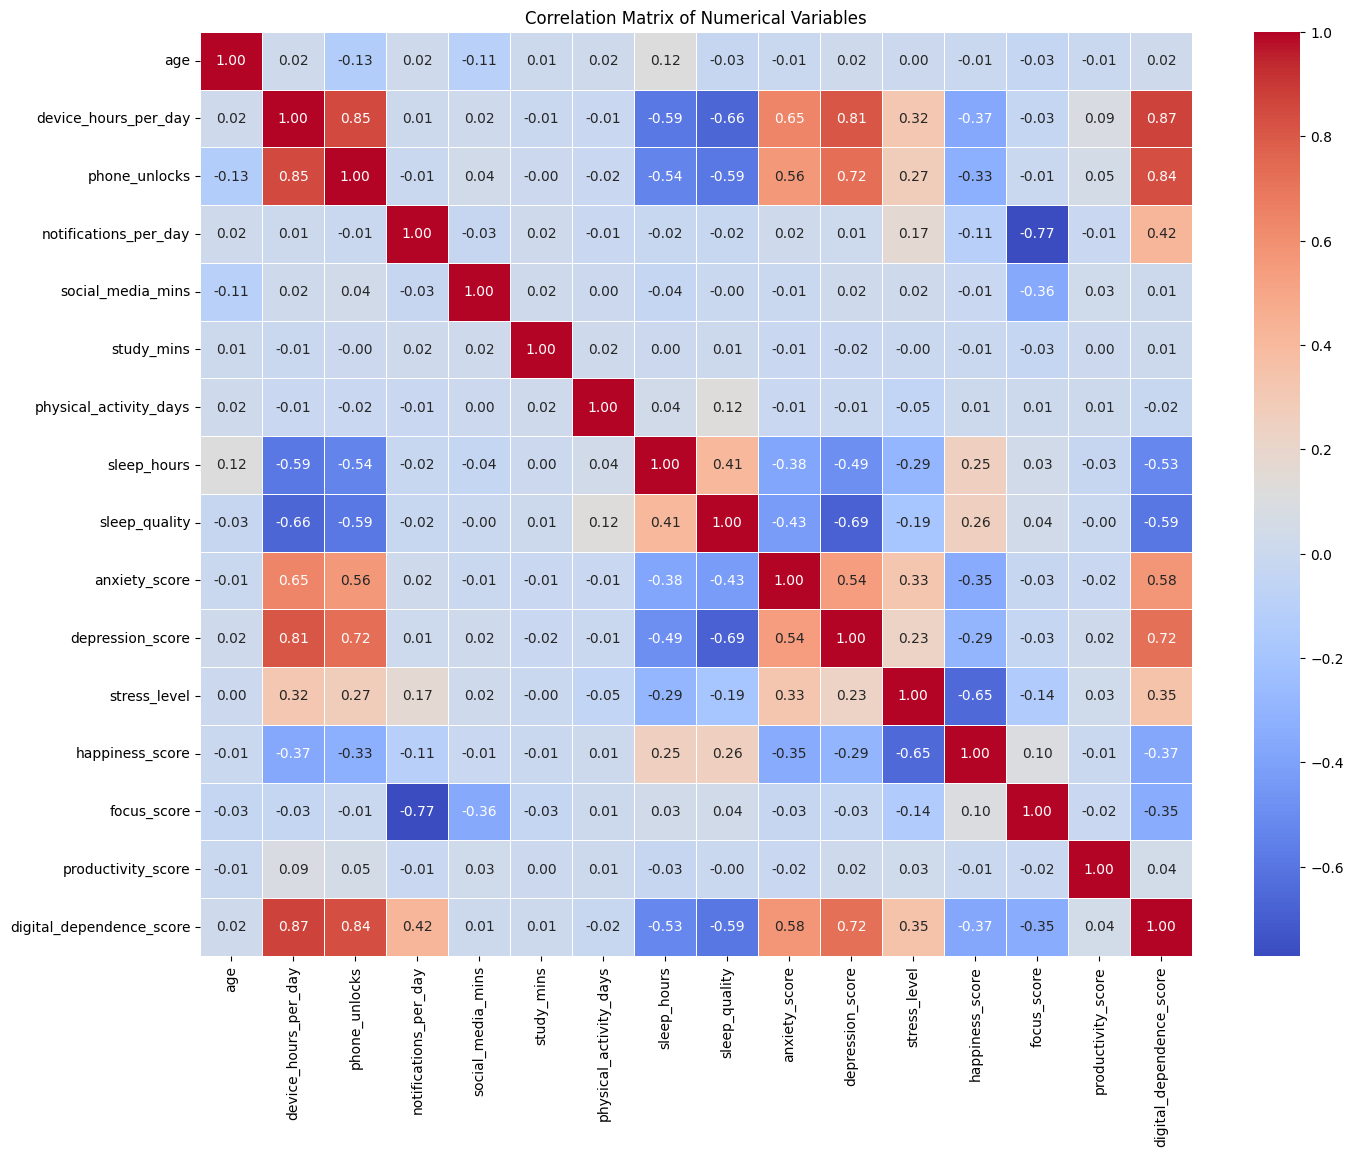

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns, excluding 'id' and 'high_risk_flag'
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['id', 'high_risk_flag']]

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


- 알림이 많을수록 집중력이 크게 떨어진다(notifications_per_day, focus_score -0.77)

- 스마트폰 잠금 해제 빈도는 우울감과 밀접하게 관련된다(phone_unlocks, depression_socre - 0.72)

- 우울·불안 점수가 높을수록 디지털 의존도가 높다
(depression_score, anxiety_score 0.58, 0.72)

- 수면 질과 시간은 디지털 의존도와 반비례한다( sleep_hours, sleep_quality-0.53,-0.59)

- 기기 사용 시간이 늘수록 불안·수면 저하가 나타난다
(device_hours_per_day, anxiety_score,sleep, -0.6,0.8)

### 변수별 High_risk_flag 값 비교

**나이대에 따른 High_risk_flag 값**

(50대의 경우 표본이 39명이기 때문에 참고 정도)

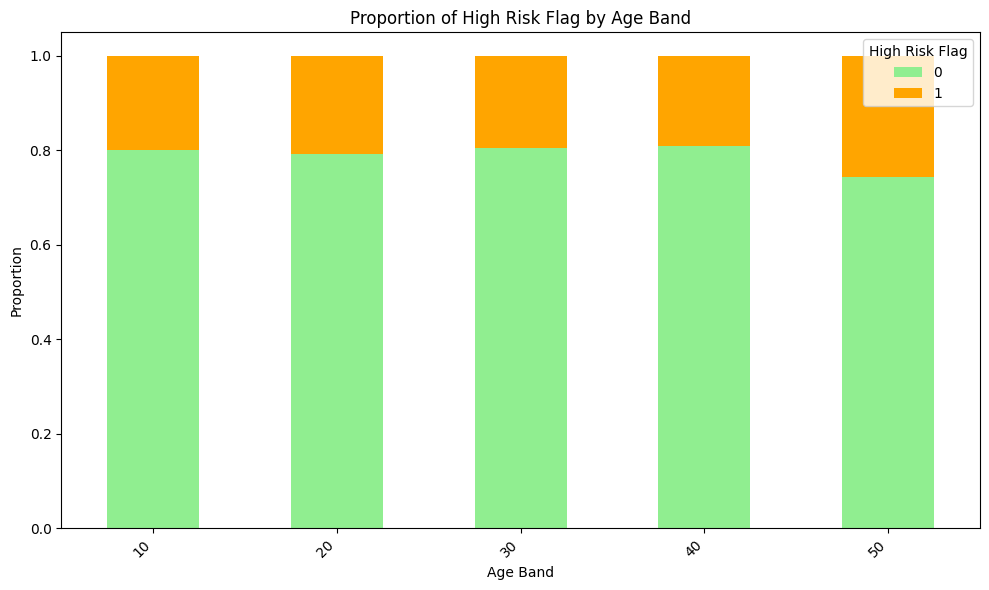

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define consistent palettes for high_risk_flag
custom_palette_stacked = {'0': 'lightgreen', '1': 'orange'}

# Calculate proportions of high_risk_flag for each age_band
# Normalize by index level 0 (the age_band itself) to get proportions within each age_band
proportions_df = df.groupby('age_band')['high_risk_flag'].value_counts(normalize=True).unstack().fillna(0)

# Ensure the columns '0' and '1' exist for consistent plotting
for flag_val in ['0', '1']:
    if flag_val not in proportions_df.columns:
        proportions_df[flag_val] = 0

# Ensure 'age_band_order_str' is available or recreate it if not
if 'age_band_order_str' not in locals():
    age_band_order = sorted(df['age_band'].unique())
    age_band_order_str = [str(band) for band in age_band_order]

# Plotting stacked bar chart with specified order
proportions_df.loc[age_band_order_str][['0', '1']].plot(kind='bar', stacked=True, figsize=(10, 6),
                                                            color=[custom_palette_stacked['0'], custom_palette_stacked['1']])

plt.title('Proportion of High Risk Flag by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='High Risk Flag')
plt.tight_layout()
plt.show()


- **나이대별 고위험군 비율은 거의 비슷**

### 범주형 변수별 High_risk_flag 값 비교

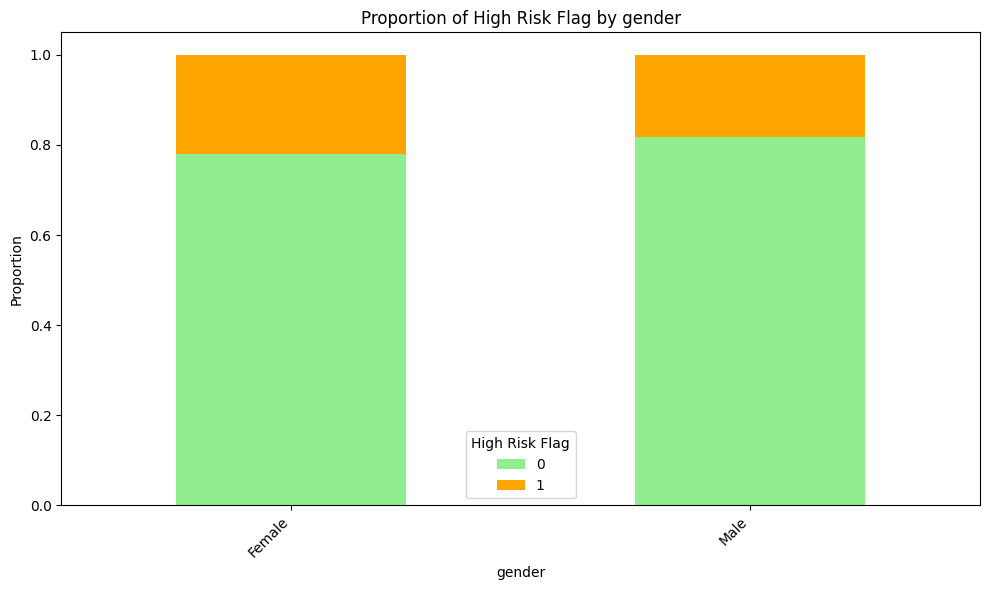

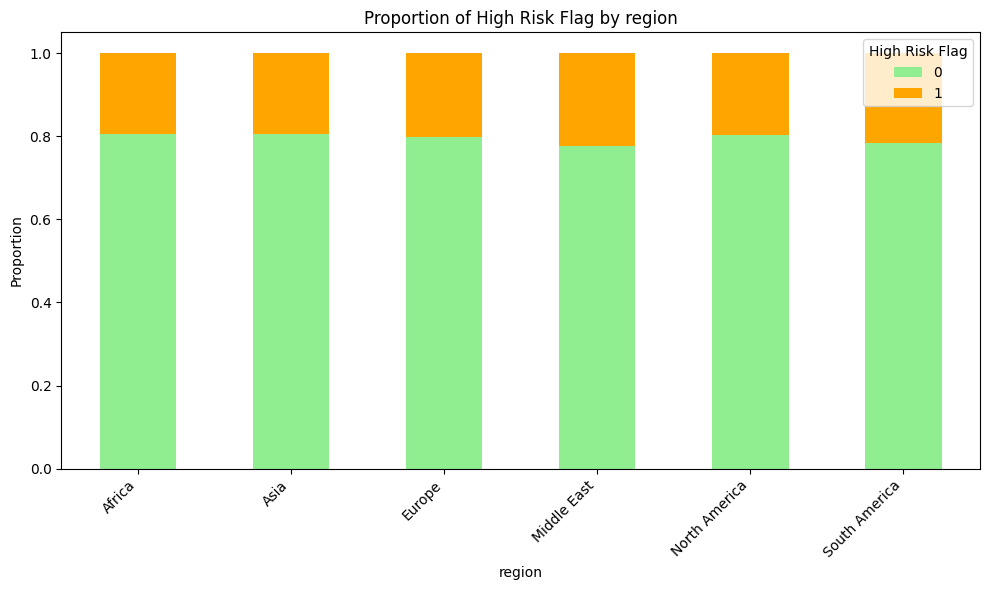

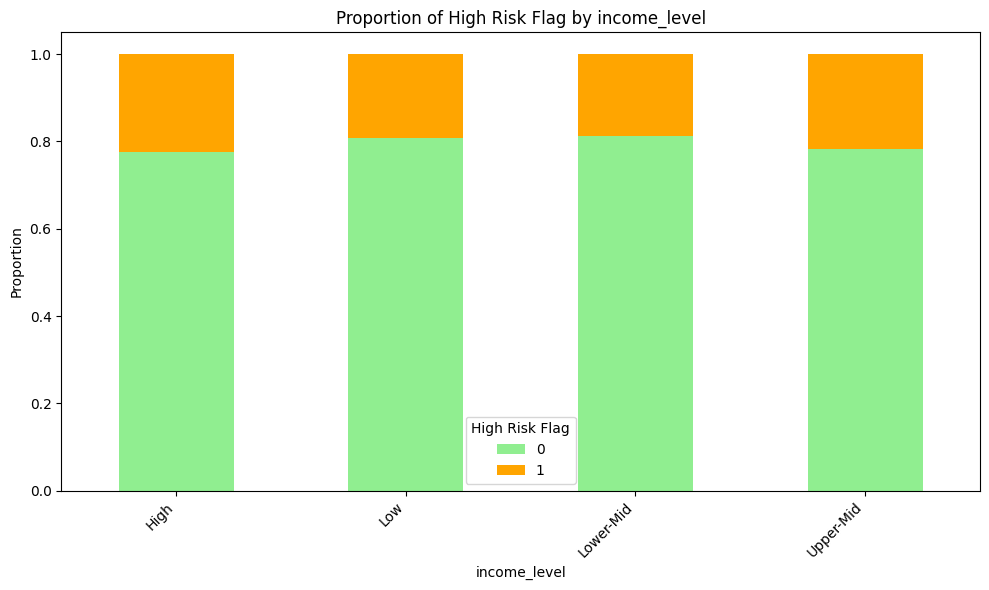

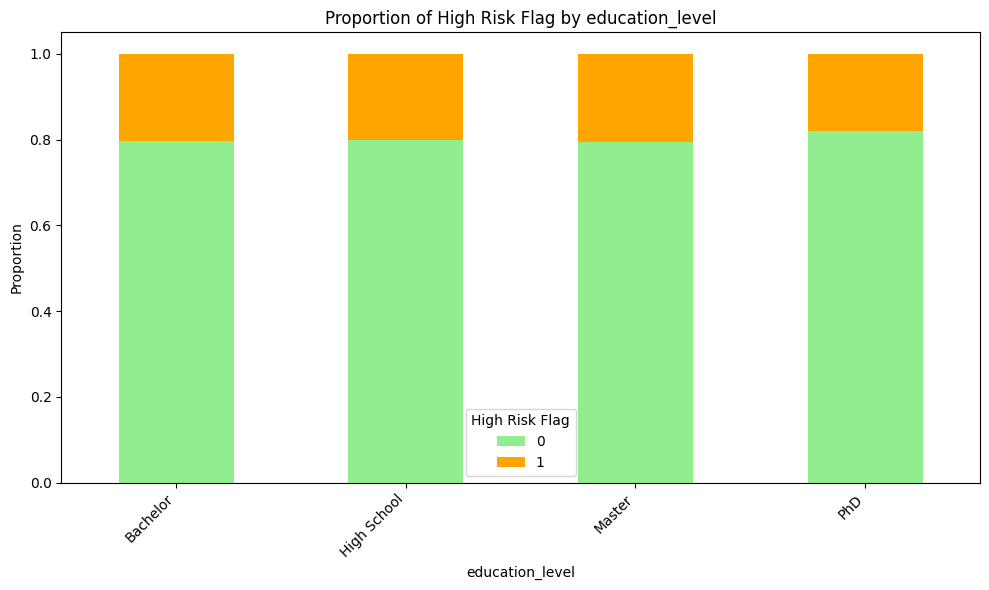

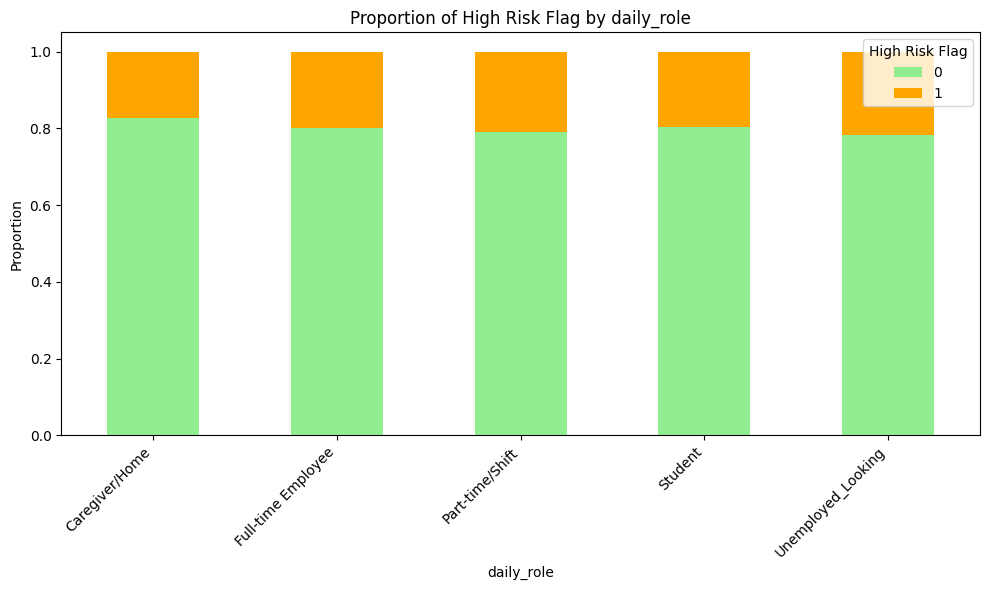

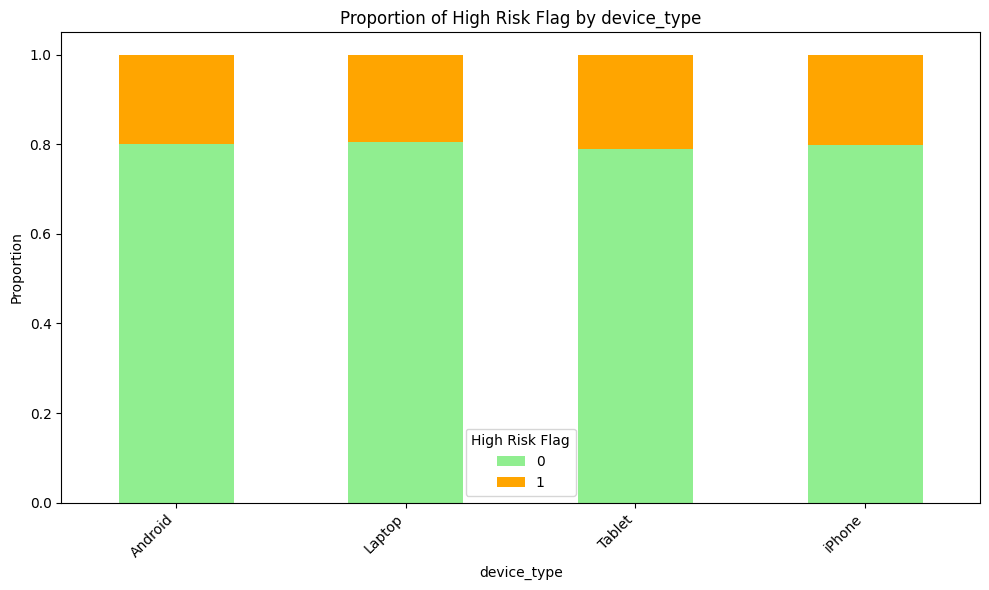

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define consistent palettes for high_risk_flag
custom_palette_stacked = {'0': 'lightgreen', '1': 'orange'}

# Get categorical columns for analysis (re-using the list from previous analysis)
analysis_categorical_cols = ['gender', 'region', 'income_level', 'education_level', 'daily_role', 'device_type']

for col in analysis_categorical_cols:
    # Calculate proportions of high_risk_flag for each category
    # Normalize by index level 0 (the category itself) to get proportions within each category
    proportions_df = df.groupby(col)['high_risk_flag'].value_counts(normalize=True).unstack().fillna(0)

    # Ensure the columns '0' and '1' exist for consistent plotting
    for flag_val in ['0', '1']:
        if flag_val not in proportions_df.columns:
            proportions_df[flag_val] = 0

    # Plotting stacked bar chart
    proportions_df[['0', '1']].plot(kind='bar', stacked=True, figsize=(10, 6), color=[custom_palette_stacked['0'], custom_palette_stacked['1']])

    plt.title(f'Proportion of High Risk Flag by {col}')
    plt.xlabel(col)
    plt.ylabel('Proportion')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='High Risk Flag')
    plt.tight_layout()
    plt.show()

대륙, 성별, 수입, 직업 모두 고위험군 분포가 비슷함;;

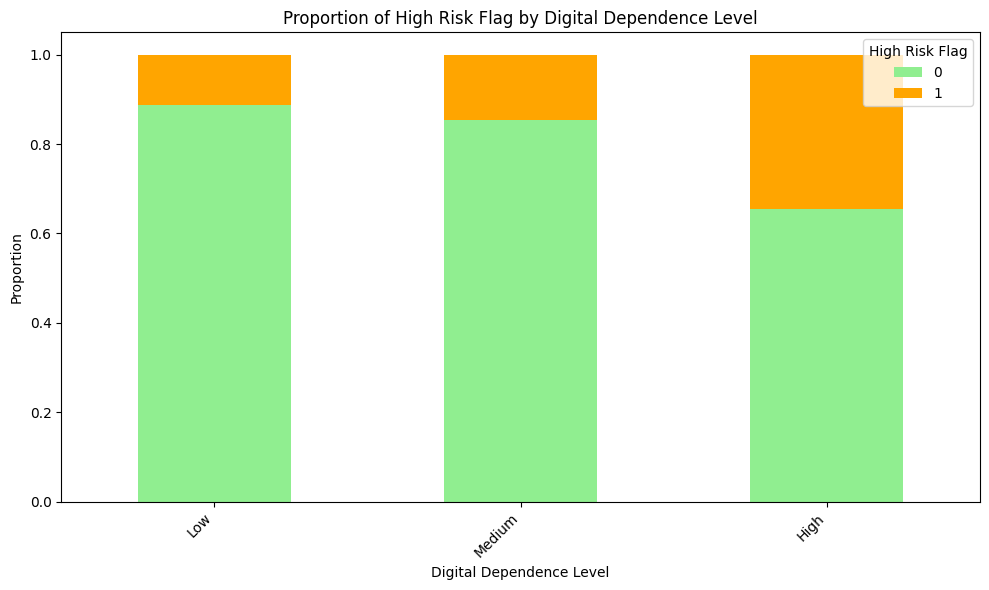

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define consistent palettes for high_risk_flag
custom_palette_stacked = {'0': 'lightgreen', '1': 'orange'}

# Define the order for digital_dependence_level
level_order = ['Low', 'Medium', 'High']

# Calculate proportions of high_risk_flag for each digital_dependence_level
# Added observed=False to suppress FutureWarning
proportions_df = df.groupby('digital_dependence_level', observed=False)['high_risk_flag'].value_counts(normalize=True).unstack().fillna(0)

# Ensure the columns '0' and '1' exist for consistent plotting
for flag_val in ['0', '1']:
    if flag_val not in proportions_df.columns:
        proportions_df[flag_val] = 0

# Plotting stacked bar chart with specified order
# Reindex to ensure the order of digital_dependence_level is maintained
proportions_df.loc[level_order][['0', '1']].plot(kind='bar', stacked=True, figsize=(10, 6),
                                                            color=[custom_palette_stacked['0'], custom_palette_stacked['1']])

plt.title('Proportion of High Risk Flag by Digital Dependence Level')
plt.xlabel('Digital Dependence Level')
plt.ylabel('Proportion')
plt.xticks(rotation=45, ha='right')
plt.legend(title='High Risk Flag')
plt.tight_layout()
plt.show()

## Digital_dependece가 낮은데 고위험군에 속한 사람들은 어떤게 문제일까(KDE 함수)

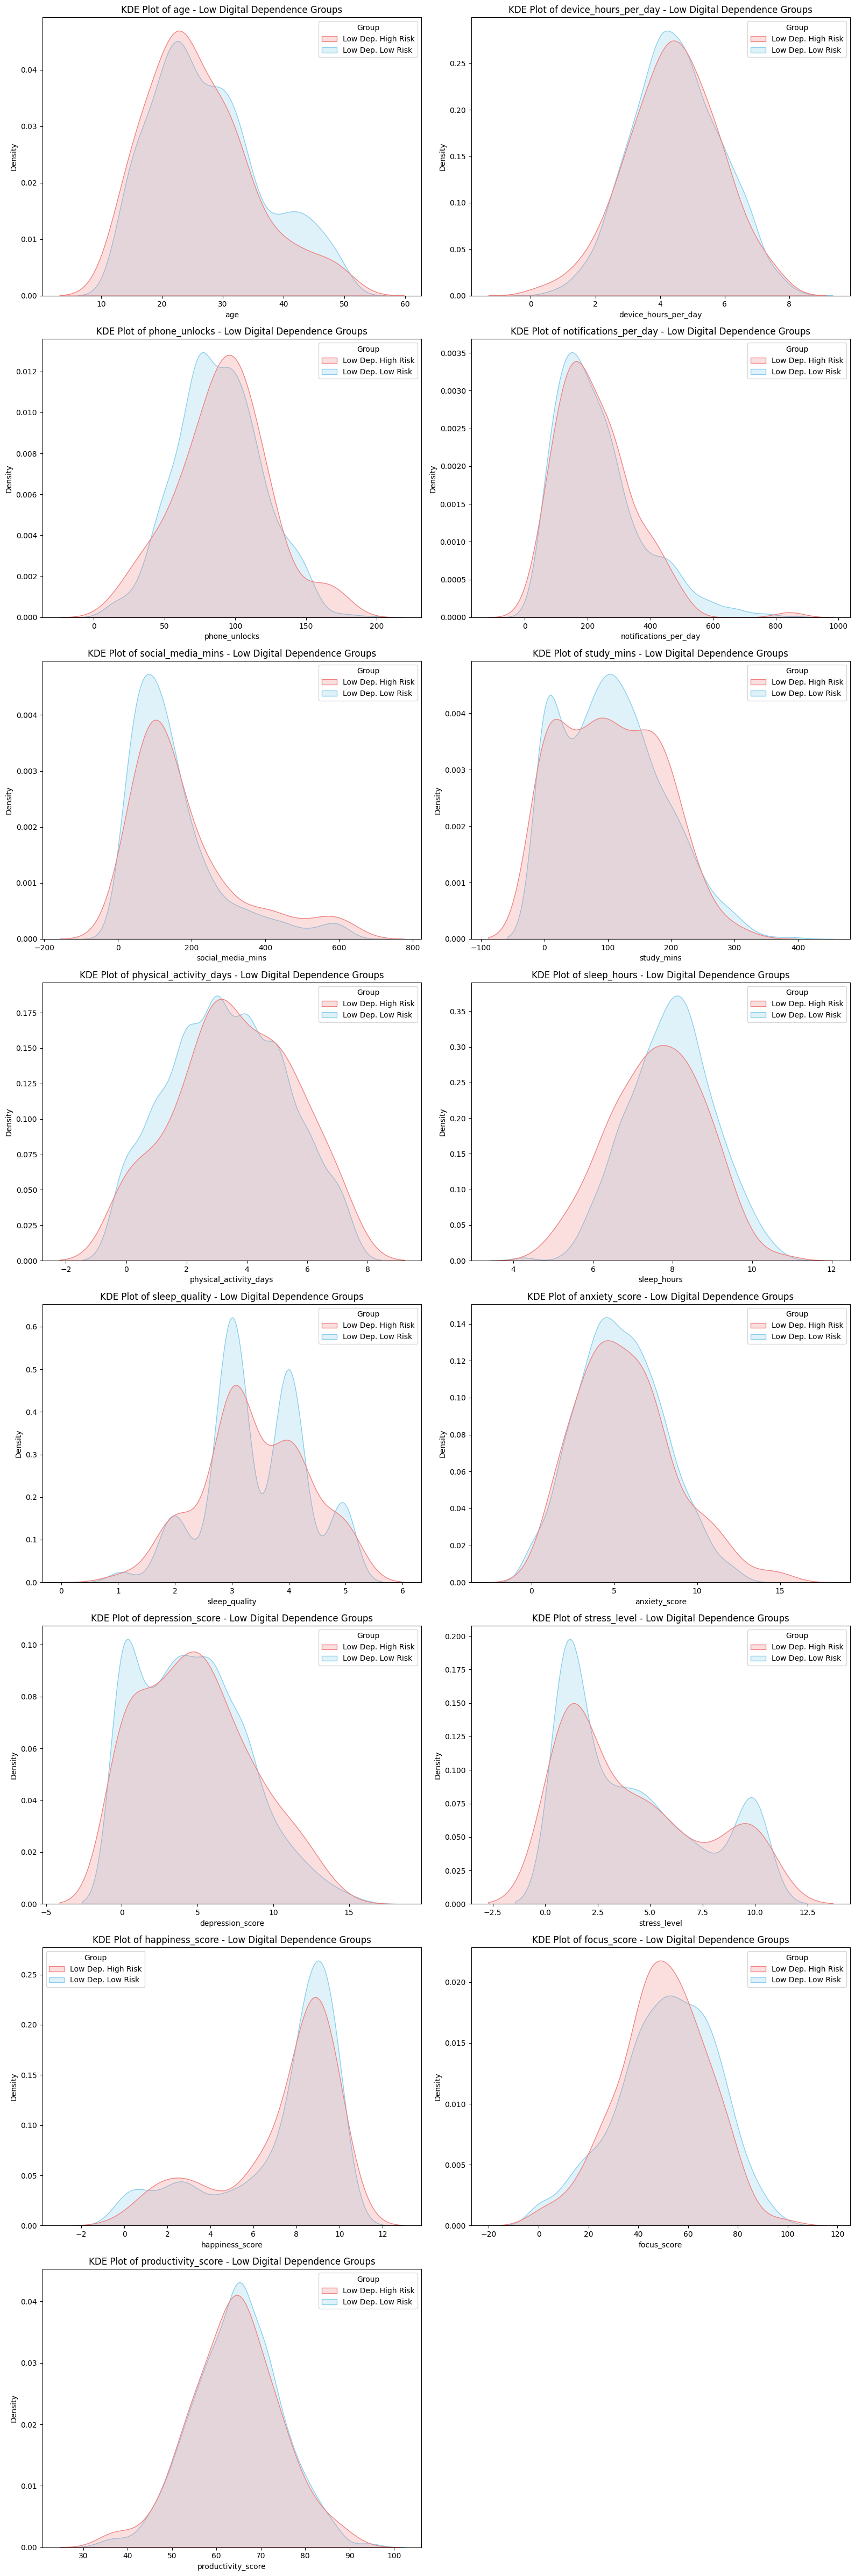

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Identify numerical columns for comparison
numerical_cols_to_compare = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols_to_compare = [col for col in numerical_cols_to_compare if col not in ['id', 'high_risk_flag', 'digital_dependence_score']]

# Combine the two dataframes with a new identifier column for plotting
df_combined = pd.concat([
    df_low_dep_high_risk.assign(Group='Low Dep. High Risk'),
    df_low_dep_low_risk.assign(Group='Low Dep. Low Risk')
])

n_cols = 2 # Number of columns for subplots
n_rows = math.ceil(len(numerical_cols_to_compare) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols_to_compare):
    sns.kdeplot(data=df_combined, x=col, hue='Group', fill=True, common_norm=False, palette={'Low Dep. High Risk': 'lightcoral', 'Low Dep. Low Risk': 'skyblue'}, ax=axes[i])
    axes[i].set_title(f'KDE Plot of {col} - Low Digital Dependence Groups')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## digital_dependce가 High지만 high_risk_flag가 0인 사람들은?(KDE 함수)

'digital_dependence_level'이 High이면서 'high_risk_flag'가 0인 사람들의 수: 759명


,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score,age_band,digital_dependence_level
2,3,31,Male,North America,Lower-Mid,Bachelor,Full-time Employee,8.87,181,231,...,8.0,1.429139,7.600000,15.0,0,Android,65.299301,40.6,30,High
15,16,24,Female,Africa,Low,Bachelor,Full-time Employee,9.74,180,1195,...,17.0,6.606128,6.418568,0.0,0,Android,59.000000,66.9,20,High
21,22,27,Male,Europe,Upper-Mid,High School,Student,7.30,141,525,...,10.0,1.000000,8.300000,35.0,0,iPhone,63.000000,40.9,20,High
25,26,23,Female,Middle East,High,Master,Part-time/Shift,5.10,98,1203,...,2.0,10.000000,0.400000,0.0,0,Android,66.000000,48.7,20,High
36,37,32,Male,Asia,Low,PhD,Unemployed_Looking,5.96,101,772,...,4.0,5.028738,9.000000,9.0,0,Android,67.000000,41.0,30,High


'digital_dependence_level'이 High이면서 'high_risk_flag'가 1인 사람들의 수: 402명


,id,age,gender,region,income_level,education_level,daily_role,device_hours_per_day,phone_unlocks,notifications_per_day,...,depression_score,stress_level,happiness_score,focus_score,high_risk_flag,device_type,productivity_score,digital_dependence_score,age_band,digital_dependence_level
4,5,26,Female,Europe,Lower-Mid,Bachelor,Full-time Employee,13.07,199,91,...,15.0,9.448757,4.2,70.0,1,Android,65.299301,48.4,20,High
19,20,15,Male,Europe,Low,High School,Student,12.66,203,703,...,18.0,9.707076,2.7,0.0,1,Tablet,51.000000,62.7,10,High
20,21,21,Female,Africa,Lower-Mid,Bachelor,Part-time/Shift,6.89,204,499,...,3.0,8.798729,9.4,30.0,1,Laptop,80.000000,43.5,20,High
26,27,46,Female,Europe,Upper-Mid,Bachelor,Unemployed_Looking,6.28,145,558,...,6.0,1.000000,8.3,18.0,1,Laptop,53.000000,41.6,40,High
28,29,50,Male,Asia,Low,Bachelor,Caregiver/Home,7.88,183,594,...,12.0,4.309486,3.0,13.0,1,iPhone,59.000000,49.8,50,High


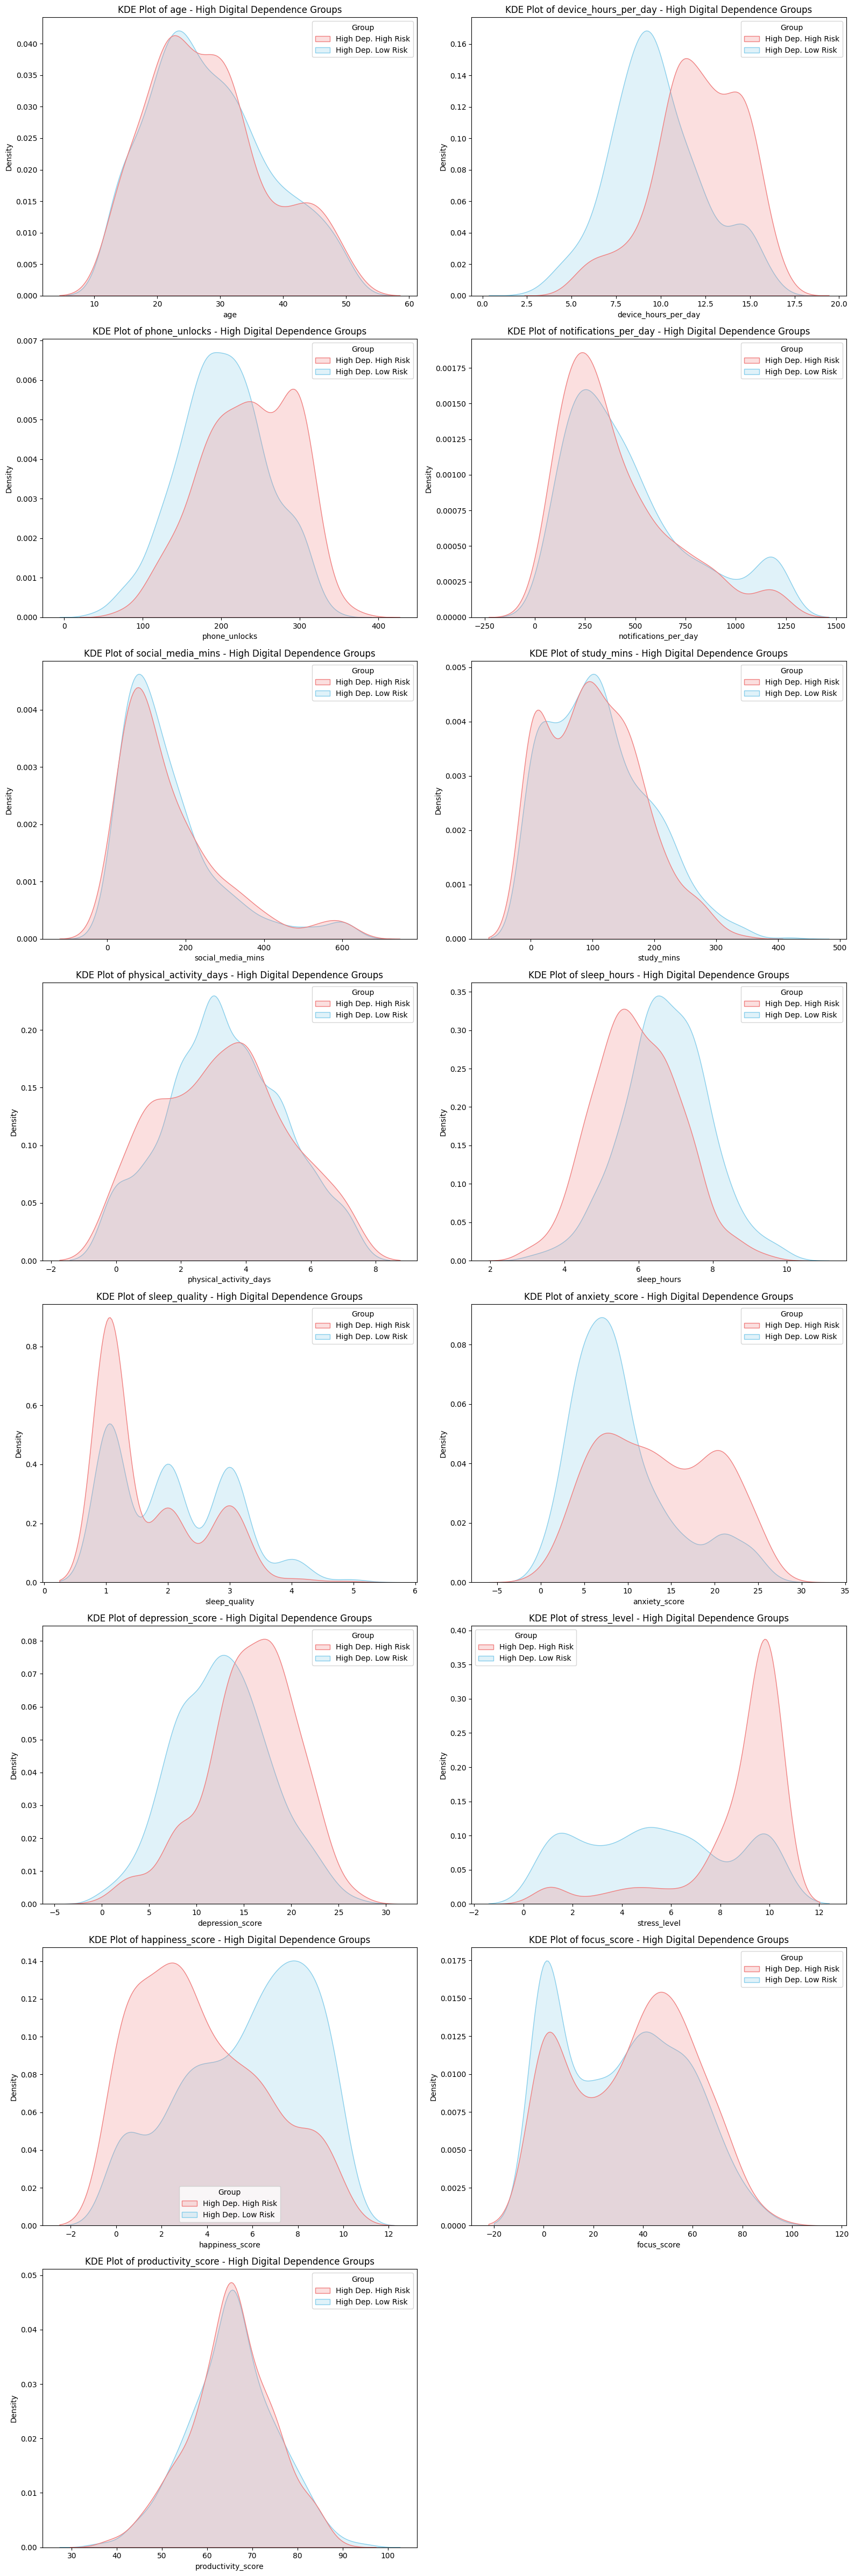

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

# 1. Filter the new group: High Digital Dependence & Low Risk Flag
df_high_dep_low_risk = df[(df['digital_dependence_level'] == 'High') & (df['high_risk_flag'] == '0')]
print(f"'digital_dependence_level'이 High이면서 'high_risk_flag'가 0인 사람들의 수: {len(df_high_dep_low_risk)}명")
display(df_high_dep_low_risk.head())

# 2. Filter the comparison group: High Digital Dependence & High Risk Flag
df_high_dep_high_risk = df[(df['digital_dependence_level'] == 'High') & (df['high_risk_flag'] == '1')]
print(f"'digital_dependence_level'이 High이면서 'high_risk_flag'가 1인 사람들의 수: {len(df_high_dep_high_risk)}명")
display(df_high_dep_high_risk.head())

# Identify numerical columns for comparison (excluding identifiers and fixed flags)
numerical_cols_to_compare = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols_to_compare = [col for col in numerical_cols_to_compare if col not in ['id', 'high_risk_flag', 'digital_dependence_score']]

# Combine the two dataframes with a new identifier column for plotting
df_combined_high_dep = pd.concat([
    df_high_dep_high_risk.assign(Group='High Dep. High Risk'),
    df_high_dep_low_risk.assign(Group='High Dep. Low Risk')
])

n_cols = 2 # Number of columns for subplots
n_rows = math.ceil(len(numerical_cols_to_compare) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numerical_cols_to_compare):
    sns.kdeplot(data=df_combined_high_dep, x=col, hue='Group', fill=True, common_norm=False, palette={'High Dep. High Risk': 'lightcoral', 'High Dep. Low Risk': 'skyblue'}, ax=axes[i])
    axes[i].set_title(f'KDE Plot of {col} - High Digital Dependence Groups')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Digital Depnedence 스코어 점수가 높고 고위험군,
Digital Dependence 스코어 점수가 낮지만 저위험군
간의 차이가 명확함
